In [1]:
from google.colab import files
uploaded = files.upload()  # upload the CSV

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
print(df.shape)
df.head()

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv
(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
df.dtypes
df.isnull().sum().sort_values(ascending=False)

# Drop columns with too many nulls or irrelevant ones
df.drop(columns=[
    'Product Description', 'Customer Password',
    'Customer Email', 'Customer Zipcode'
], inplace=True)

# Fix date columns
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Rename columns for easier use
df.rename(columns={
    'order date (DateOrders)': 'OrderDate',
    'shipping date (DateOrders)': 'ShippingDate',
    'Days for shipping (real)': 'ActualShippingDays',
    'Days for shipment (scheduled)': 'ScheduledShippingDays',
    'Delivery Status': 'DeliveryStatus',
    'Order Item Quantity': 'Quantity',
    'Order Item Total': 'OrderTotal',
    'Order Profit Per Order': 'Profit',
    'Product Price': 'ProductPrice',
    'Customer Segment': 'CustomerSegment',
    'Order Region': 'Region',
    'Category Name': 'Category'
}, inplace=True)

KeyError: "['Product Description', 'Customer Password', 'Customer Email', 'Customer Zipcode'] not found in axis"

In [4]:
df['OnTime'] = df['ActualShippingDays'] <= df['ScheduledShippingDays']
on_time_rate = df['OnTime'].mean() * 100
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

On-Time Delivery Rate: 42.72%


In [5]:
df['LateDelivery'] = df['ActualShippingDays'] > df['ScheduledShippingDays']
late_by_region = df.groupby('Region')['LateDelivery'].mean() * 100
print(late_by_region.sort_values(ascending=False))

Region
Central Africa     60.703637
Western Europe     58.515622
South Asia         58.504721
South of  USA      58.096415
Southeast Asia     57.983017
East of USA        57.975416
West Asia          57.497088
East Africa        57.451404
Eastern Europe     57.448980
Central America    57.245686
South America      57.234684
Central Asia       57.142857
US Center          57.125871
Eastern Asia       56.730769
Southern Europe    56.727813
North Africa       56.683168
West of USA        56.599525
Northern Europe    56.413399
Southern Africa    56.266206
Oceania            56.109578
Caribbean          55.878817
West Africa        55.005411
Canada             51.929093
Name: LateDelivery, dtype: float64


In [6]:
df['FulfillmentGap'] = df['ActualShippingDays'] - df['ScheduledShippingDays']
avg_gap = df['FulfillmentGap'].mean()
print(f"Avg Fulfillment Gap (days): {avg_gap:.2f}")

Avg Fulfillment Gap (days): 0.57


In [7]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.839896
Box

In [8]:
turnover = df.groupby('Category').agg(
    TotalRevenue=('OrderTotal', 'sum'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()
turnover['AvgOrderValue'] = turnover['TotalRevenue'] / turnover['TotalQuantity']
print(turnover)

                Category  TotalRevenue  TotalQuantity  AvgOrderValue
0            Accessories  1.197125e+05           5349      22.380361
1        As Seen on  TV!  1.851961e+04            206      89.901019
2                  Baby   1.095740e+04            207      52.934300
3    Baseball & Softball  8.436727e+04           1785      47.264578
4             Basketball  2.470533e+04             67     368.736263
5                 Books   1.130342e+04            405      27.909679
6           Boxing & MMA  7.628672e+04           1265      60.305707
7                   CDs   2.750030e+03            271      10.147712
8               Cameras   2.404967e+05            592     406.244390
9       Camping & Hiking  3.700784e+06          13729     269.559591
10      Cardio Equipment  3.320251e+06          37587      88.335081
11   Children's Clothing  2.092684e+05            652     320.963774
12                Cleats  3.982857e+06          73734      54.016553
13             Computers  5.953950

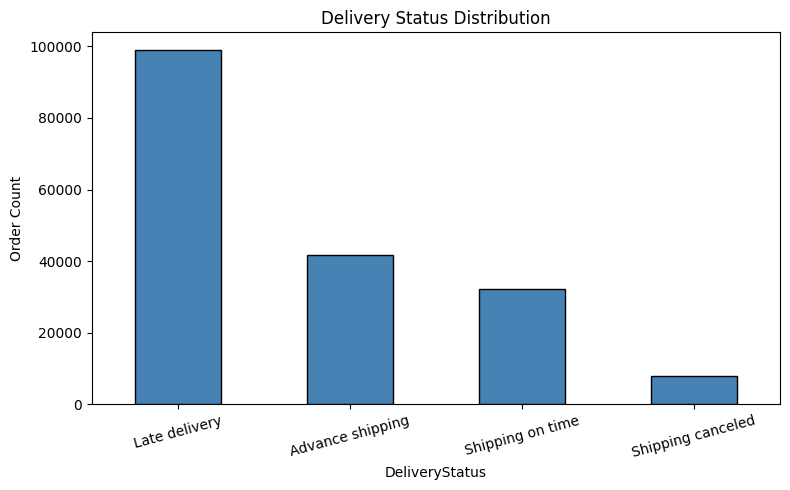

In [9]:
plt.figure(figsize=(8,5))
df['DeliveryStatus'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Delivery Status Distribution')
plt.ylabel('Order Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('delivery_status.png', dpi=150)
plt.show()

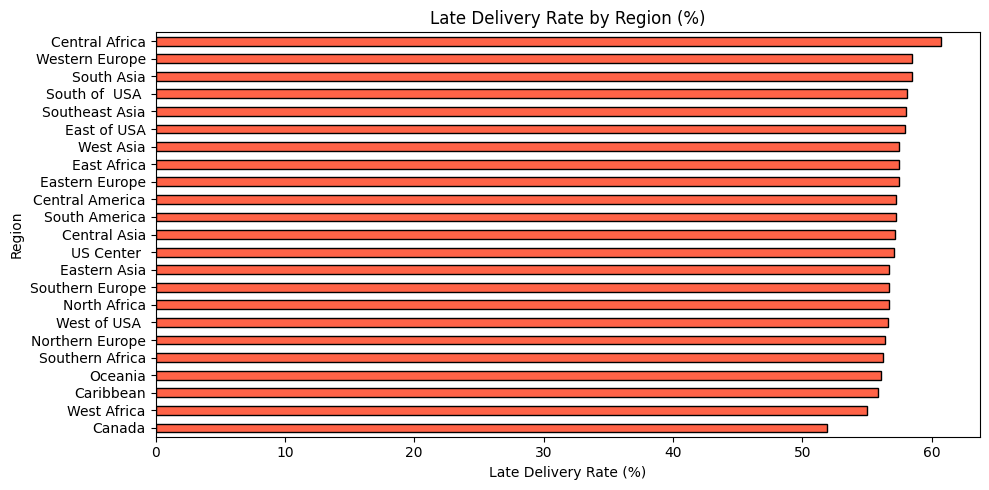

In [10]:
plt.figure(figsize=(10,5))
late_by_region.sort_values().plot(kind='barh', color='tomato', edgecolor='black')
plt.title('Late Delivery Rate by Region (%)')
plt.xlabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.savefig('late_by_region.png', dpi=150)
plt.show()

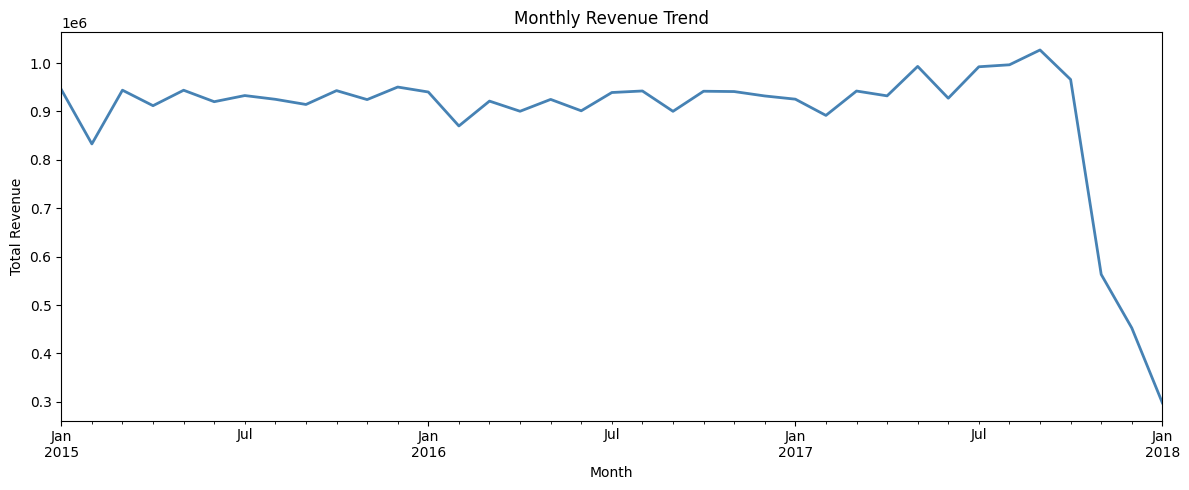

In [11]:
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
monthly_orders = df.groupby('OrderMonth')['OrderTotal'].sum()

plt.figure(figsize=(12,5))
monthly_orders.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

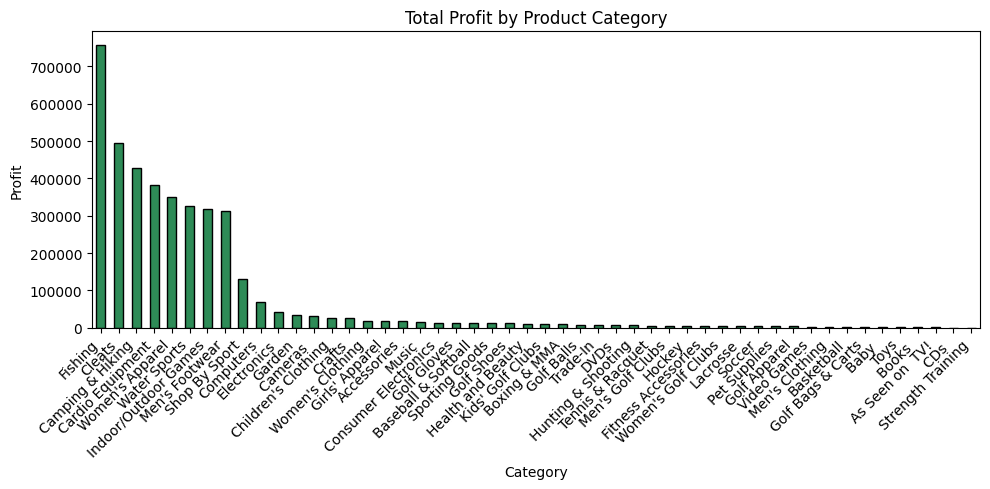

In [12]:
plt.figure(figsize=(10,5))
category_profit.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Total Profit by Product Category')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('profit_category.png', dpi=150)
plt.show()

In [13]:
df.to_csv('supply_chain_clean.csv', index=False)
files.download('supply_chain_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>